<>:108: SyntaxWarning: invalid escape sequence '\s'
<>:108: SyntaxWarning: invalid escape sequence '\d'
<>:108: SyntaxWarning: invalid escape sequence '\s'
<>:108: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3095/3584756897.py:108: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Figura 4.1 - Reticolo Binomiale CRR ($\sigma$ = {sigma*100:.2f}%, SOFR = {r*100:.2f}%, $\delta$ = {delta*100:.1f}%)",
/tmp/ipykernel_3095/3584756897.py:108: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"Figura 4.1 - Reticolo Binomiale CRR ($\sigma$ = {sigma*100:.2f}%, SOFR = {r*100:.2f}%, $\delta$ = {delta*100:.1f}%)",


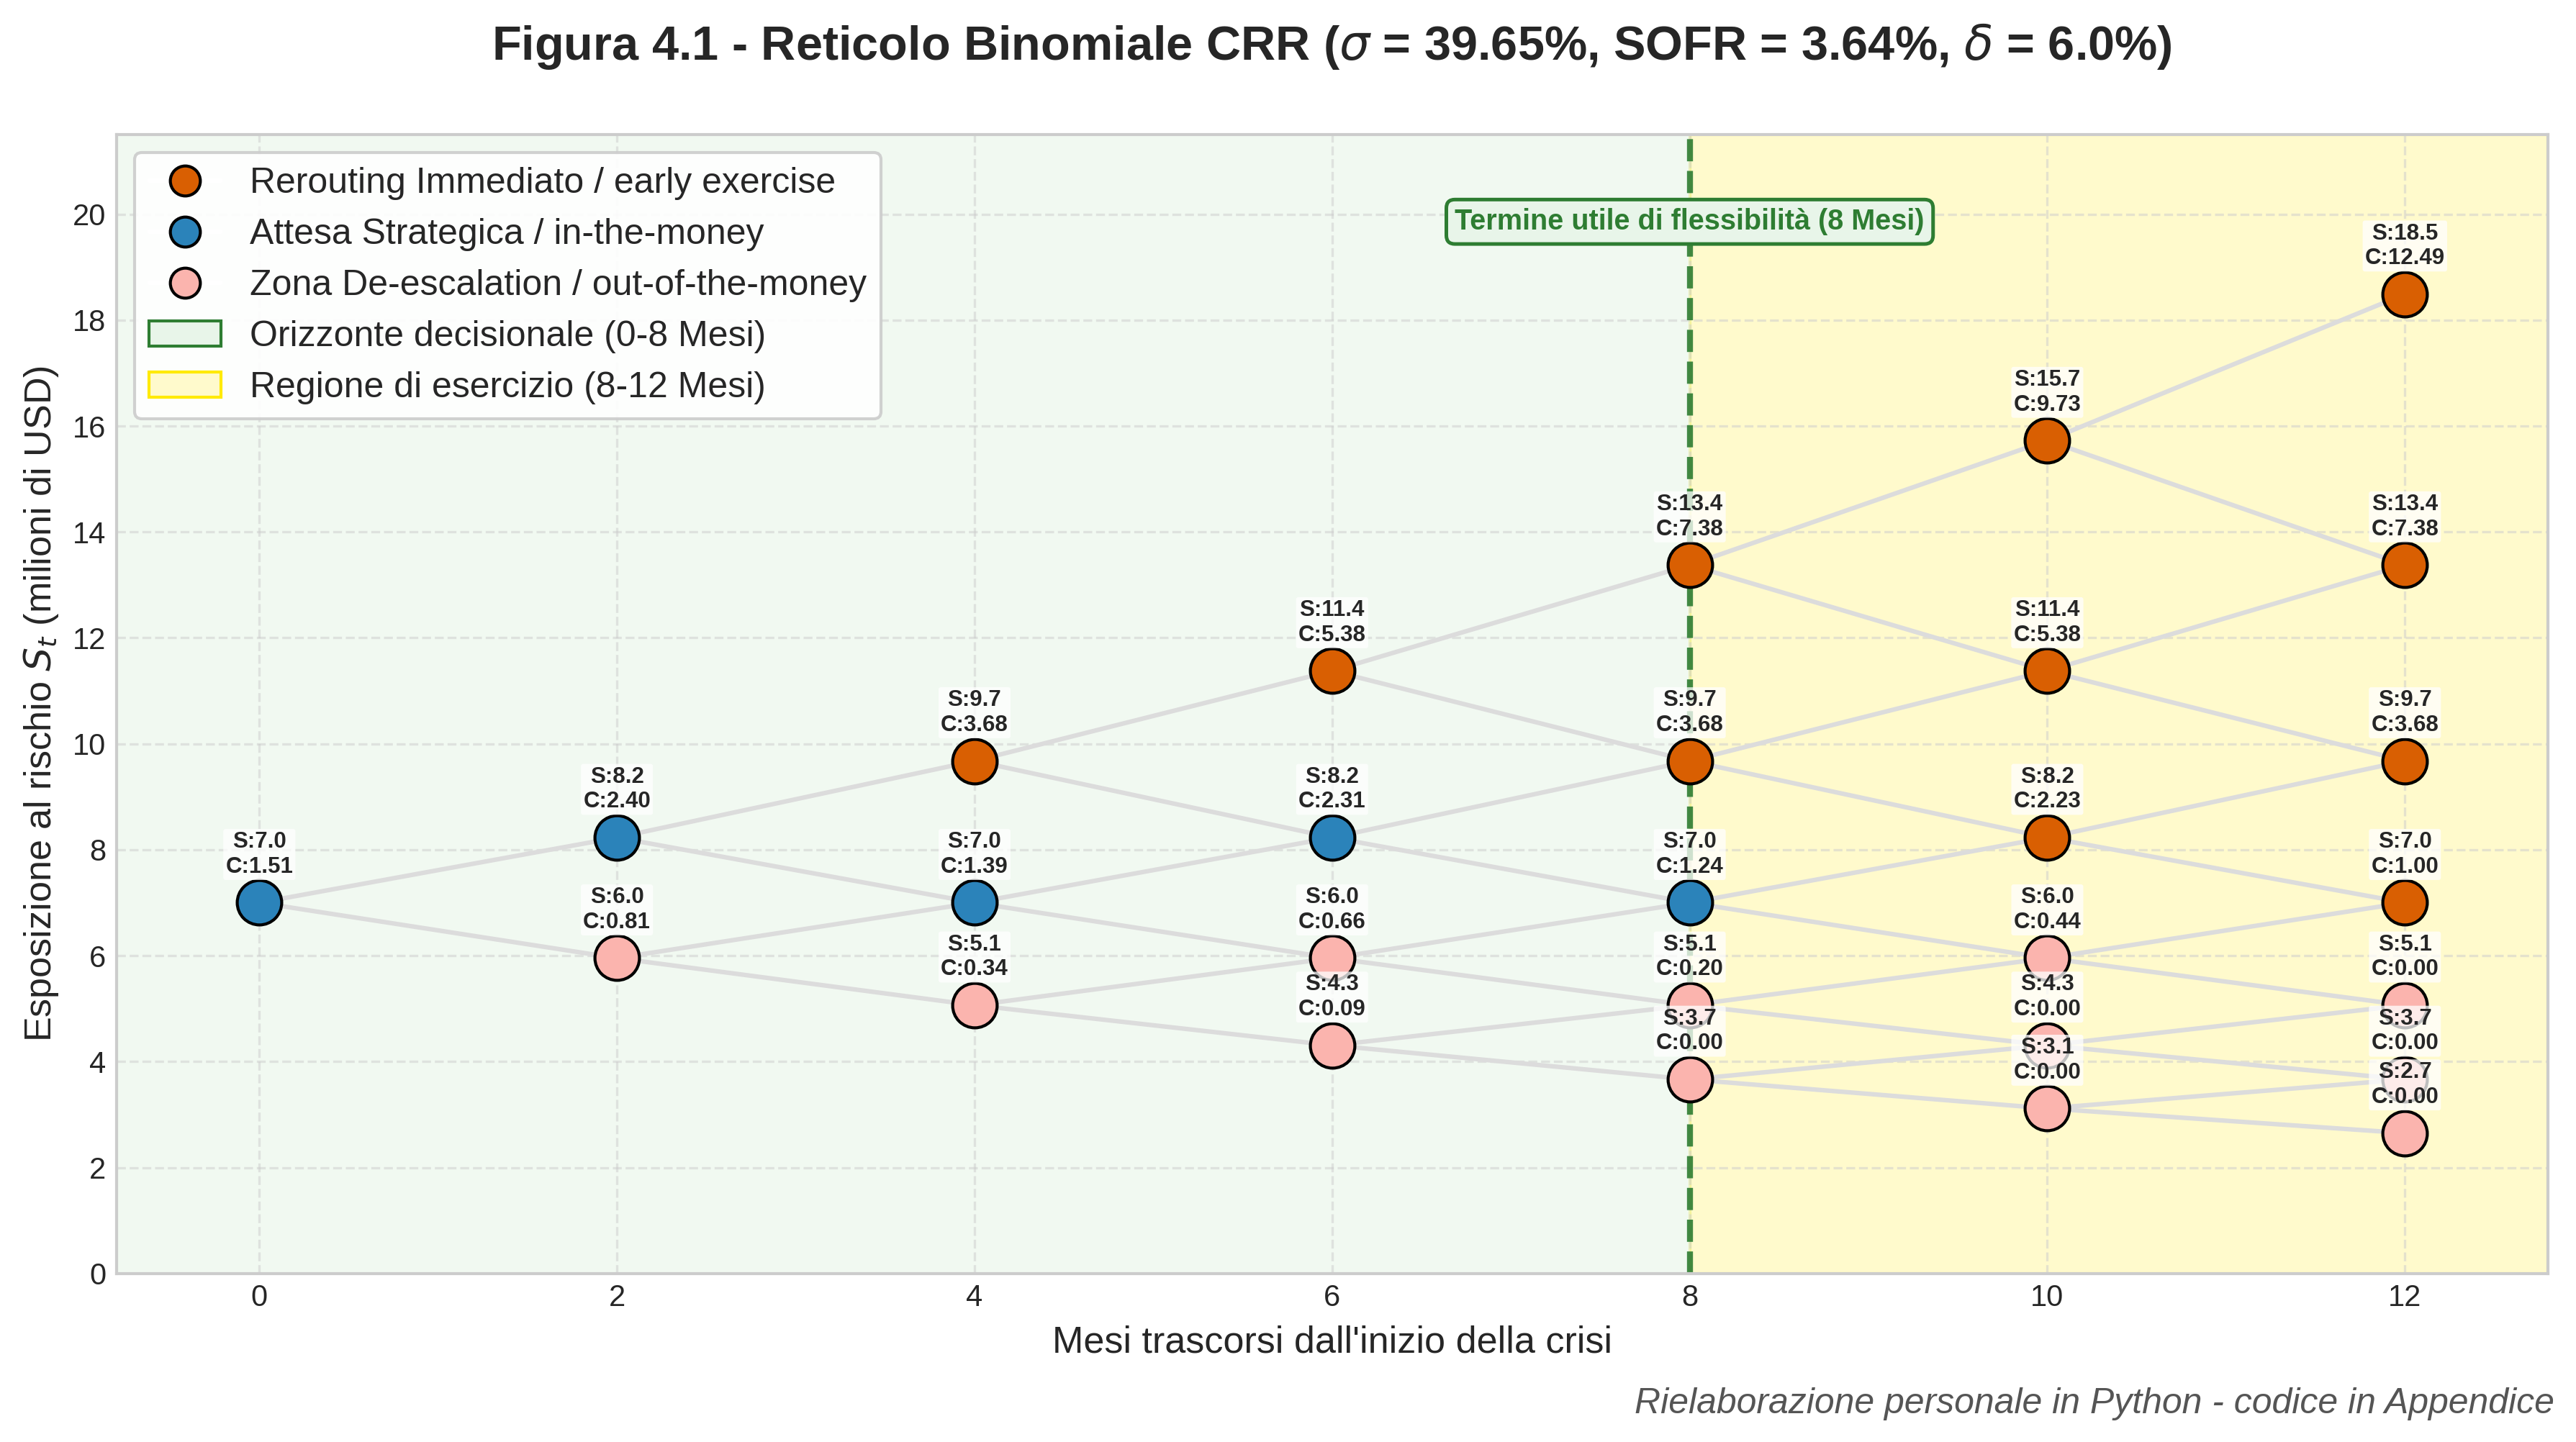

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# data at jan 22, 2026
S0 = 7.0 #million usd
K = 6.0 #million usd
sigma = 0.3965 #HV60 TF21!
r = 0.0364 #sofr
delta = 0.06 #waiting cost
T = 1.0 #1y
N = 6 #2 months span

dt = T / N
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u
gamma = np.exp(-r * dt)
q = (np.exp((r - delta) * dt) - d) / (u - d)

# tree
S = np.zeros((N + 1, N + 1))
C = np.zeros((N + 1, N + 1))
early_ex = np.full((N + 1, N + 1), False)

for i in range(N + 1):
    for j in range(i + 1):
        S[j, i] = S0 * (u**(i - j)) * (d**j)

# payoff at terminal nodes
for j in range(N + 1):
    C[j, N] = max(S[j, N] - K, 0.0)

# backward induction
for i in range(N - 1, -1, -1):
    for j in range(i + 1):
        holding_val = gamma * (q * C[j, i + 1] + (1 - q) * C[j + 1, i + 1])
        exercise_val = max(S[j, i] - K, 0.0)

        if exercise_val > holding_val and exercise_val > 0:
            C[j, i] = exercise_val
            early_ex[j, i] = True
        else:
            C[j, i] = holding_val

# graph
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)

dt_months = dt * 12 #2 months span
max_months = T * 12 #12 months
useful_limit_months = 8.0

# x_sep settled at 8.0
x_sep = useful_limit_months

# background color
ax.axvspan(-0.8, x_sep, color='#e8f5e9', alpha=0.6, zorder=0)  # verde (0-8 mesi)
ax.axvspan(x_sep, max_months + 0.8, color='#ffea00', alpha=0.2, zorder=0) # giallo (8-12 mesi)

# line
ax.axvline(x=x_sep, color='#2e7d32', linestyle='--', linewidth=2.0, alpha=0.9, zorder=2)
y_max_data = np.max(S) #centered
ax.text(x_sep, y_max_data * 1.06, 'Termine utile di flessibilità (8 Mesi)',
        color='#2e7d32', fontweight='bold', fontsize=9.5, ha='center', va='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc="#e8f5e9", ec="#2e7d32", lw=1.2), zorder=5)

# connection
for i in range(N):
    for j in range(i + 1):
        ax.plot([i * dt_months, (i + 1) * dt_months], [S[j, i], S[j, i + 1]], color='gainsboro', zorder=1)
        ax.plot([i * dt_months, (i + 1) * dt_months], [S[j, i], S[j + 1, i + 1]], color='gainsboro', zorder=1)

# nodes
for i in range(N + 1):
    for j in range(i + 1):
        val_S = S[j, i]
        val_C = C[j, i]
        t_month = i * dt_months

        # color descript
        if i == N: # terminal nodes
            node_color = '#d95f02' if val_C > 0 else '#fbb4ae'
        elif early_ex[j, i]:
            node_color = '#d95f02'  #orange / early exerc
        elif val_S <= K or val_S < S0:
            node_color = '#fbb4ae'  #pink / deescalation
        else:
            node_color = '#2b83ba'  #blue / attesa

        ax.scatter(t_month, val_S, color=node_color, s=220, zorder=4, edgecolors='black')

        txt = f"S:{val_S:.1f}\nC:{val_C:.2f}"
        ax.annotate(txt, (t_month, val_S), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=7.5, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75), zorder=5)

# legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Rerouting Immediato / early exercise', markerfacecolor='#d95f02', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Attesa Strategica / in-the-money', markerfacecolor='#2b83ba', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Zona De-escalation / out-of-the-money', markerfacecolor='#fbb4ae', markersize=10, markeredgecolor='black'),
    Patch(facecolor='#e8f5e9', edgecolor='#2e7d32', label='Orizzonte decisionale (0-8 Mesi)'),
    Patch(facecolor='#fffacc', edgecolor='#ffea00', label='Regione di esercizio (8-12 Mesi)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, facecolor='white', framealpha=0.9)

ax.set_title(f"Figura 4.1 - Reticolo Binomiale CRR ($\sigma$ = {sigma*100:.2f}%, SOFR = {r*100:.2f}%, $\delta$ = {delta*100:.1f}%)",
             fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel("Mesi trascorsi dall'inizio della crisi", fontsize=12.5)
ax.set_ylabel("Esposizione al rischio $S_t$ (milioni di USD)", fontsize=12.5)

ax.set_xticks([i * dt_months for i in range(N + 1)])
ax.set_xlim(-0.8, max_months + 0.8)

# y axis
y_max_tick = int(np.ceil(np.max(S))) + 2 #max arrotondato
y_ticks = list(range(0, y_max_tick + 1, 2)) #pari
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(y) for y in y_ticks]) #etichette unica stringa
ax.set_ylim(0, y_max_tick + 0.5)

plt.grid(True, linestyle='--', alpha=0.5)

# subtitle
plt.figtext(0.99, -0.02, 'Rielaborazione personale in Python - codice in Appendice',
            ha='right', va='bottom', fontsize=12, color='#555555', fontstyle='italic')

plt.tight_layout()

#export pdf
plt.savefig("binomiale.pdf", format="pdf", bbox_inches="tight")
plt.show()


<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3095/2406188420.py:38: SyntaxWarning: invalid escape sequence '\d'
  "$\delta$",


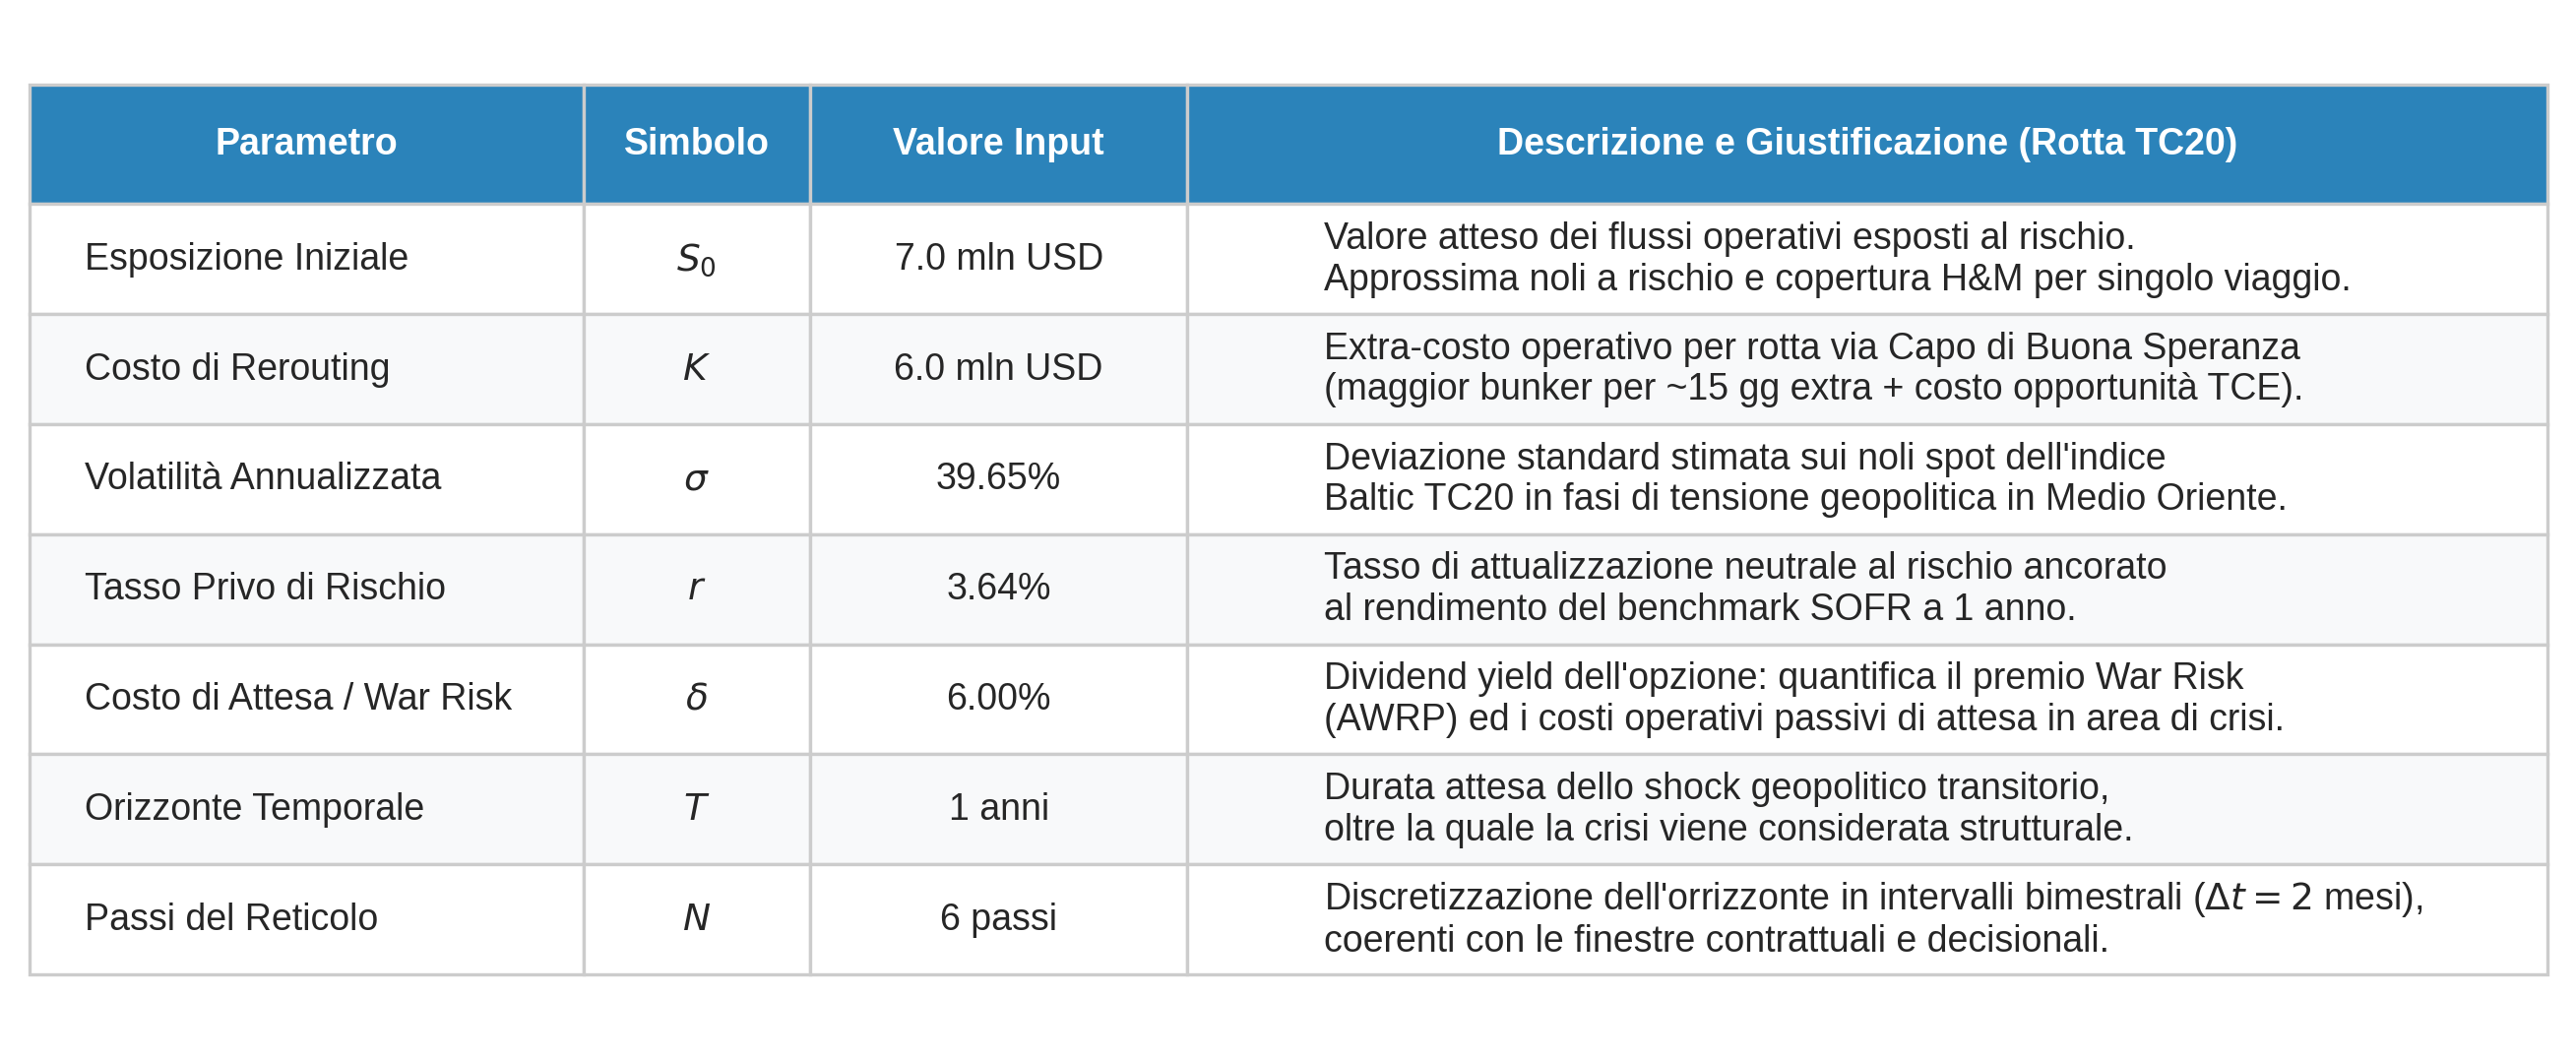

In [6]:
import matplotlib.pyplot as plt

# initial data
columns = [
    "Parametro",
    "Simbolo",
    "Valore Input",
    "Descrizione e Giustificazione (Rotta TC20)",
]

data = [
    [
        "Esposizione Iniziale",
        "$S_0$",
        f"{S0:.1f} mln USD",
        "Valore atteso dei flussi operativi esposti al rischio.\nApprossima noli a rischio e copertura H&M per singolo viaggio.",
    ],
    [
        "Costo di Rerouting",
        "$K$",
        f"{K:.1f} mln USD",
        "Extra-costo operativo per rotta via Capo di Buona Speranza\n(maggior bunker per ~15 gg extra + costo opportunità TCE).",
    ],
    [
        "Volatilità Annualizzata",
        "$\\sigma$",
        f"{sigma*100:.2f}%",
        "Deviazione standard stimata sui noli spot dell'indice\nBaltic TC20 in fasi di tensione geopolitica in Medio Oriente.",
    ],
    [
        "Tasso Privo di Rischio",
        "$r$",
        f"{r*100:.2f}%",
        "Tasso di attualizzazione neutrale al rischio ancorato\nal rendimento del benchmark SOFR a 1 anno.",
    ],
    [
        "Costo di Attesa / War Risk",
        "$\delta$",
        f"{delta*100:.2f}%",
        "Dividend yield dell'opzione: quantifica il premio War Risk\n(AWRP) ed i costi operativi passivi di attesa in area di crisi.",
    ],
    [
        "Orizzonte Temporale",
        "$T$",
        f"{T:.0f} anni",
        "Durata attesa dello shock geopolitico transitorio,\noltre la quale la crisi viene considerata strutturale.",
    ],
    [
        "Passi del Reticolo",
        "$N$",
        f"{N:.0f} passi",
        "Discretizzazione dell'orrizzonte in intervalli bimestrali ($\\Delta t = 2$ mesi),\ncoerenti con le finestre contrattuali e decisionali.",
    ],
]

# tab graphics
fig, ax = plt.subplots(figsize=(11, 4.4), dpi=300)
ax.axis("off")
ax.axis("tight")

# creating tab
table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc="left",
    loc="center",
    colWidths=[0.22, 0.09, 0.15, 0.54],
)

table.auto_set_font_size(True)

# graphic details
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.8)
    cell.set_edgecolor("#cccccc")

    if row == 0:
        # column
        cell.set_text_props(
            weight="bold", color="white", fontsize=14, ha="center")
        cell.set_facecolor("#2b83ba")
        cell.set_height(0.12)
    else:
        # tab
        cell.set_height(0.11)

        # centered value and symbol
        if col in [1, 2]:
            cell.get_text().set_ha("center")

        # lines
        if row % 2 == 0:
            cell.set_facecolor("#f8f9fa")
        else:
            cell.set_facecolor("#ffffff")

# export pdf
plt.savefig("tabella_parametri.pdf", format="pdf", bbox_inches="tight")
plt.show()

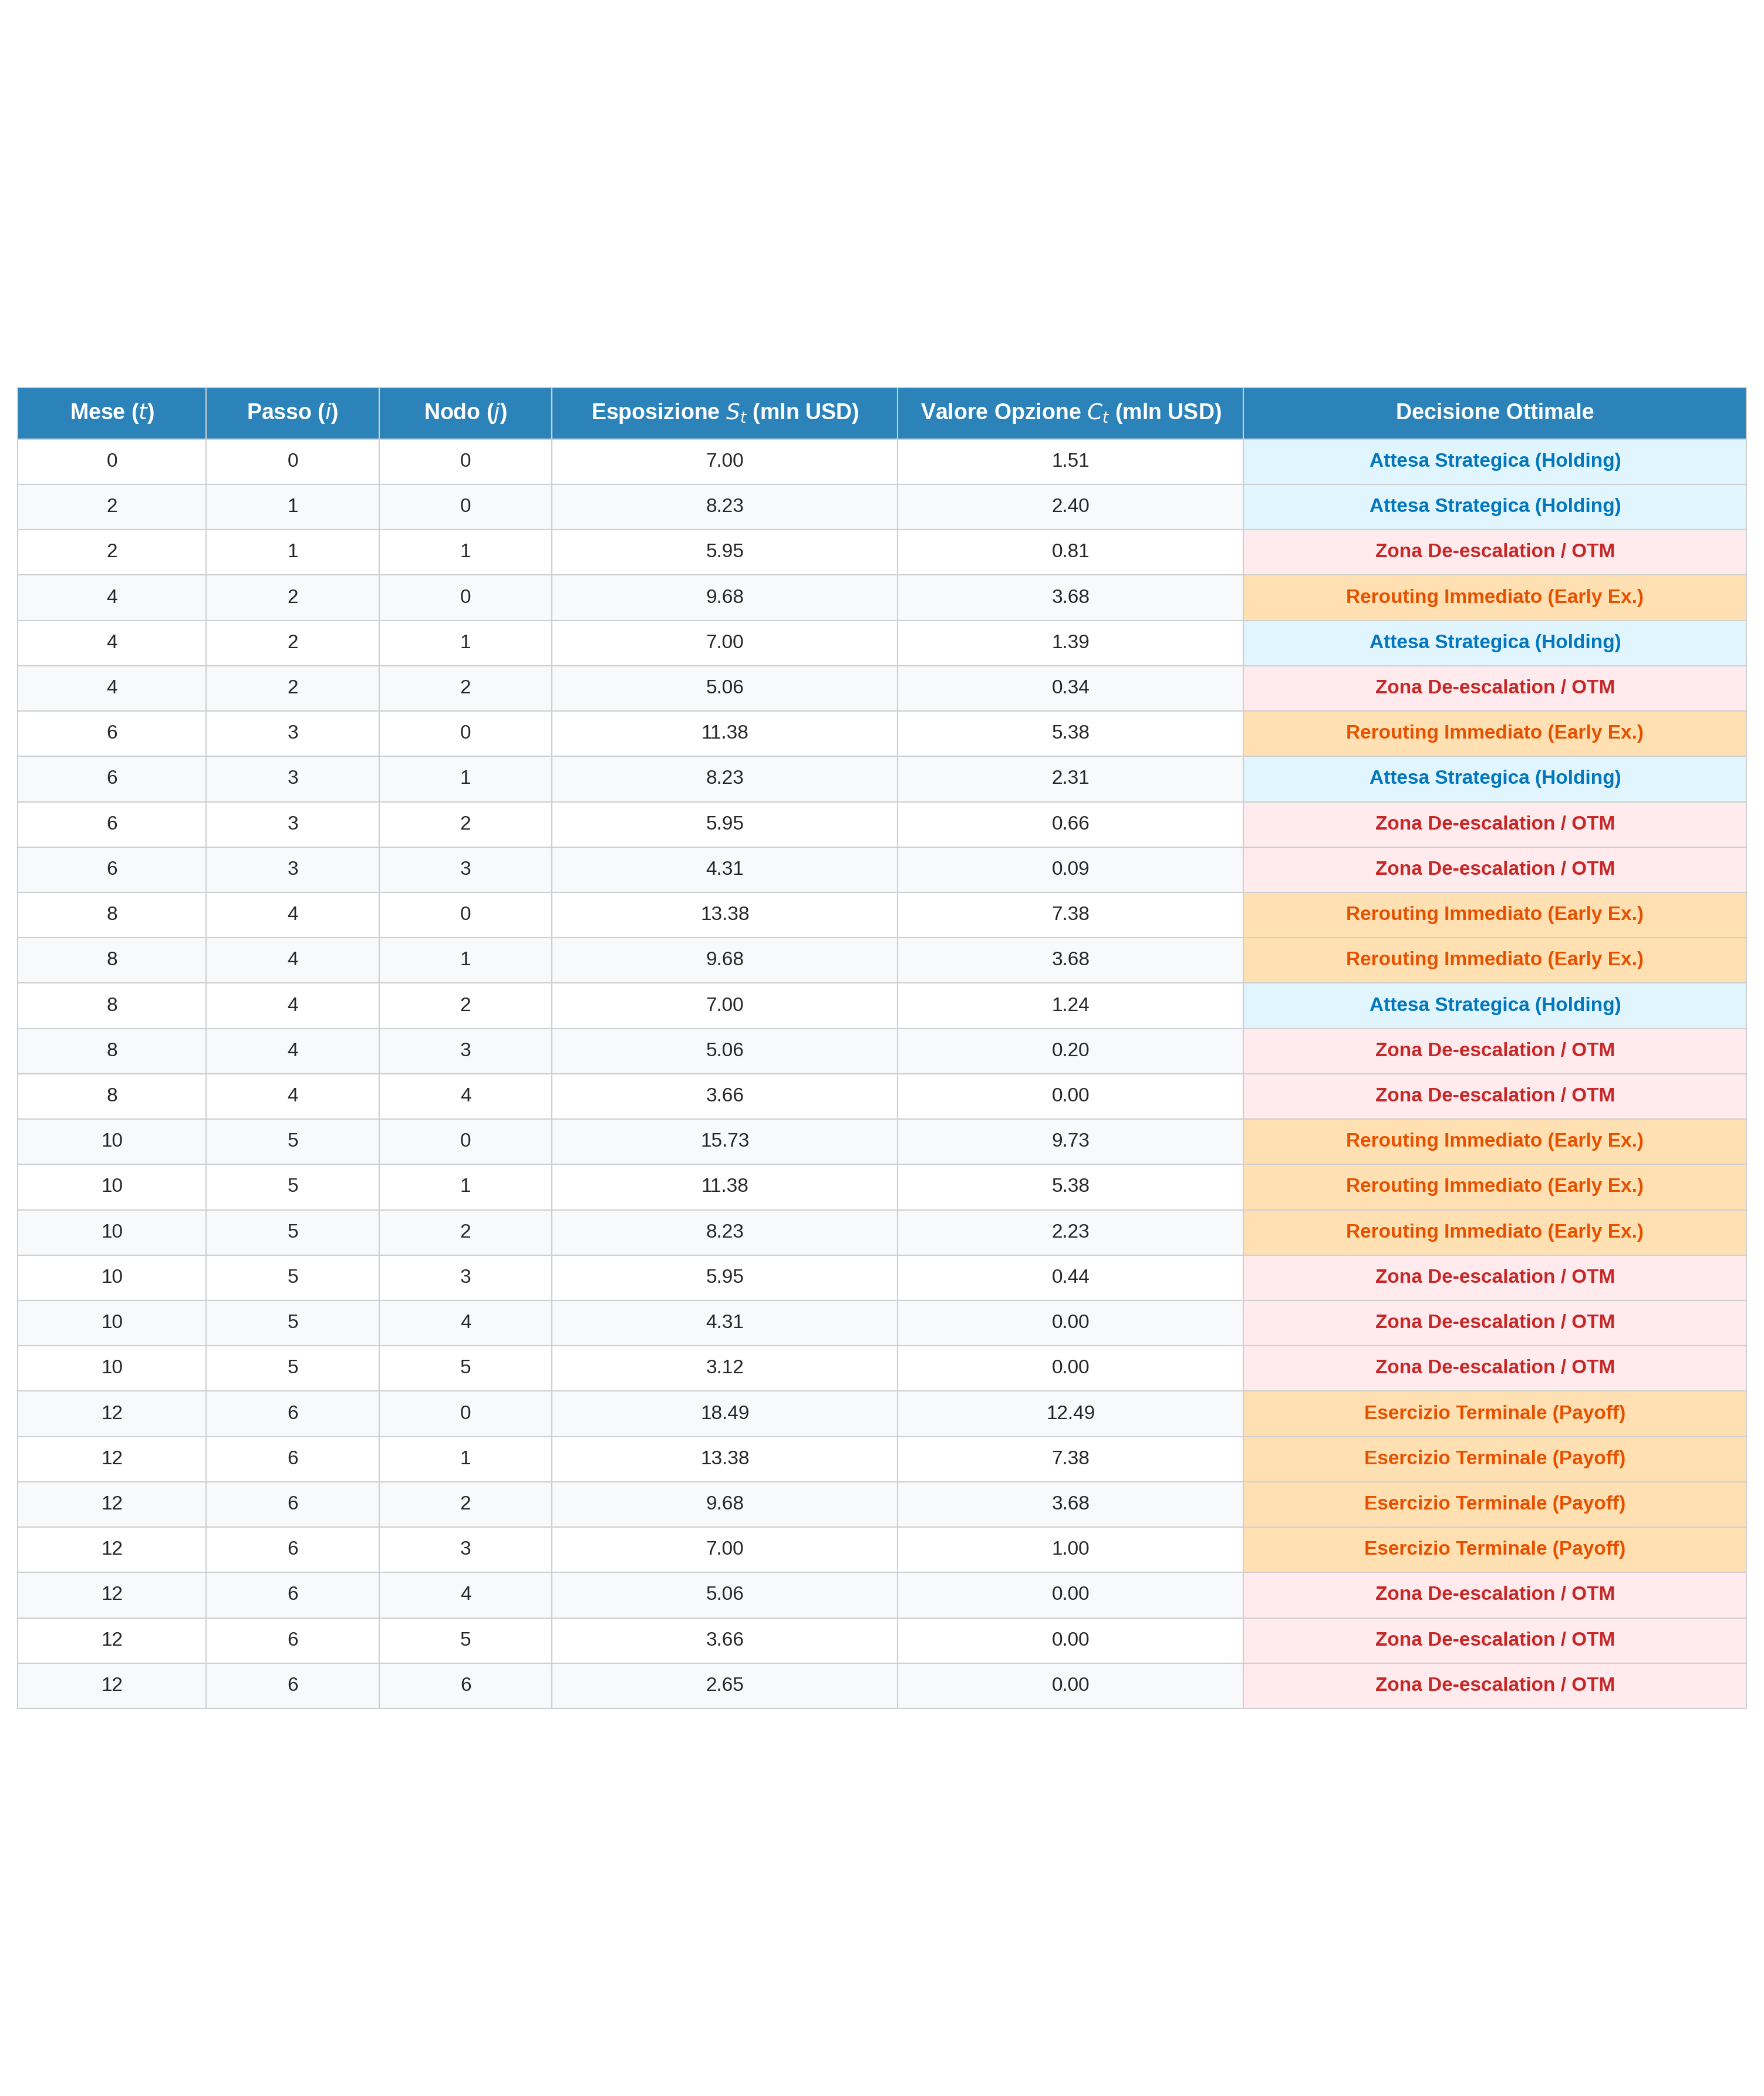

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# exctracting and organizing nodes data
records = []

for i in range(N + 1):
    m_month = int(round(i * dt_months))
    for j in range(i + 1):
        val_S = S[j, i]
        val_C = C[j, i]

        # decisional procedure
        if i == N:
            decision = (
                "Esercizio Terminale (Payoff)"
                if val_C > 0
                else "Zona De-escalation / OTM"
            )
        elif early_ex[j, i]:
            decision = "Rerouting Immediato (Early Ex.)"
        elif val_S <= K or val_S < S0:
            decision = "Zona De-escalation / OTM"
        else:
            decision = "Attesa Strategica (Holding)"

        records.append([
            str(m_month),
            str(i),
            str(j),
            f"{val_S:.2f}",
            f"{val_C:.2f}",
            decision,
        ])

columns = [
    "Mese ($t$)",
    "Passo ($i$)",
    "Nodo ($j$)",
    "Esposizione $S_t$ (mln USD)",
    "Valore Opzione $C_t$ (mln USD)",
    "Decisione Ottimale",
]

# dimensions
fig, ax = plt.subplots(figsize=(10, 12), dpi=300)
ax.axis("off")
ax.axis("tight")

table = ax.table(
    cellText=records,
    colLabels=columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.12, 0.11, 0.11, 0.22, 0.22, 0.32],
)

table.auto_set_font_size(False)
table.set_fontsize(8)

# graphic details
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor("#d0d0d0")

    if row == 0:
        # blue
        cell.set_text_props(weight="bold", color="white", fontsize=9)
        cell.set_facecolor("#2b83ba")
        cell.set_height(0.025)
    else:
        cell.set_height(0.022)
        decision_val = records[row - 1][5]

        if (
            "Rerouting Immediato" in decision_val
            or "Esercizio Terminale" in decision_val
        ):
            bg_color = "#ffe0b2"  # orange
            txt_color = "#e65100"
        elif "Attesa Strategica" in decision_val:
            bg_color = "#e1f5fe"  # blue
            txt_color = "#0277bd"
        elif "De-escalation" in decision_val:
            bg_color = "#ffebee"  # pink
            txt_color = "#c62828"
        else:
            bg_color = "#ffffff"
            txt_color = "#000000"

        # optimal highlighting
        if col == 5:
            cell.set_facecolor(bg_color)
            cell.set_text_props(weight="bold", color=txt_color)
        else:
            # zebra striping
            cell.set_facecolor("#f8f9fa" if row % 2 == 0 else "#ffffff")

plt.tight_layout()

# export pdf
plt.savefig("tabella_nodi_binomiale.pdf", format="pdf", bbox_inches="tight")
plt.show()

# export xlsx
df_tree = pd.DataFrame(records, columns=columns)
df_tree.to_excel("tabella_nodi_binomiale.xlsx", index=False)